#Step 1: Import Required Libraries

In [26]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn libraries for preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# TensorFlow libraries for deep learning model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Step 2: Load Dataset

In [27]:
# Loading Adult Income dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Column names
columns = ['age','workclass','fnlwgt','education','education-num',
           'marital-status','occupation','relationship','race','sex',
           'capital-gain','capital-loss','hours-per-week',
           'native-country','income']

# Read dataset
df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Display first five rows
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Step 3: Data Preprocessing

In [28]:
# Checking missing values
print(df.isnull().sum())

# Removing rows with missing values
df.dropna(inplace=True)

# Convert text columns into numeric values
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

# Separate input features and target output
X = df.drop("income", axis=1)
y = df["income"]

# Standardize the input data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


# Step 4: Build Neural Network Model

In [29]:
# Creating Sequential model
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(32, activation='relu'))

# Dropout layer to reduce overfitting
model.add(Dropout(0.3))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 5: Compile the Model

In [30]:
# Compile model using Adam optimizer
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 6: Train the Model

In [31]:
# Train model with training data
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8144 - loss: 0.3967 - val_accuracy: 0.8393 - val_loss: 0.3404
Epoch 2/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8385 - loss: 0.3438 - val_accuracy: 0.8478 - val_loss: 0.3307
Epoch 3/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8437 - loss: 0.3359 - val_accuracy: 0.8457 - val_loss: 0.3274
Epoch 4/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8450 - loss: 0.3307 - val_accuracy: 0.8472 - val_loss: 0.3265
Epoch 5/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8468 - loss: 0.3288 - val_accuracy: 0.8478 - val_loss: 0.3253
Epoch 6/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8466 - loss: 0.3272 - val_accuracy: 0.8495 - val_loss: 0.3242
Epoch 7/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8461 - loss: 0.3263 - val_accuracy: 0.8499 - val_loss: 0.3222
Epoch 8/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8493 - loss: 0.3254 - val_accuracy: 0.

# Step 7: Evaluate the Model

In [33]:
# Evaluate model performance on test data
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8560 - loss: 0.3155
Test Accuracy: 0.8559803366661072
Test Loss: 0.3154766261577606


# Step 8: Generate Predictions

In [34]:
# Predict output values
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Display classification report
print(classification_report(y_test, y_pred))

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4942
           1       0.76      0.59      0.66      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.76      0.79      6513
weighted avg       0.85      0.86      0.85      6513



# Step 9: Plot Accuracy and Loss Graphs

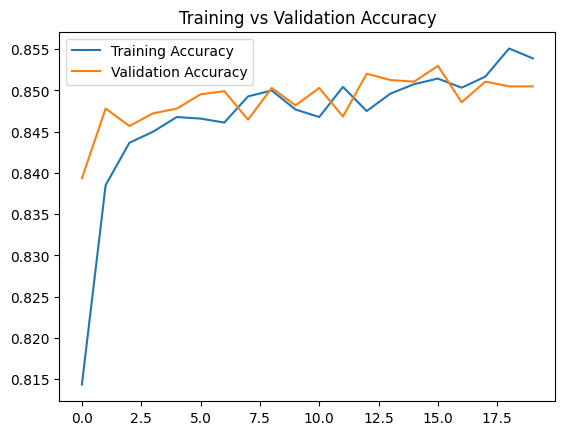

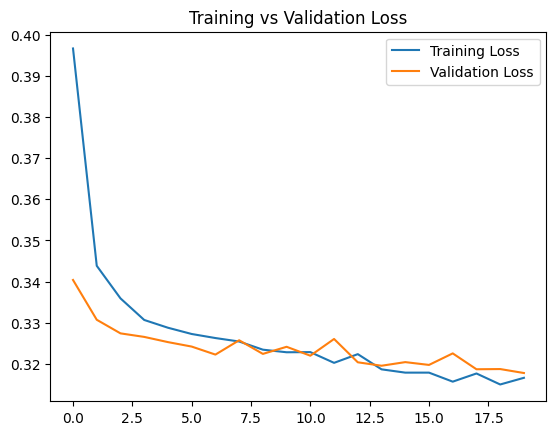

In [35]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()